# Optical Properties with VASP

Many of the properties we are interested in can be calculated with a "optics" calculation. This involves calculating a well-sampled general electronic structure and using it to simulate optical absorption.

`solphin` provides methods to write input files and read output files to calculate this using VASP.

Pre-requisites:
* Geometry Optimisation/Structural Relaxation

## Calculation

1) Import the necessary libraries.

In [13]:
import solphin.vasp_inputs as vasp_inputs

2) Define our computational regime. This should be the same regime used to relax the structure.

In [14]:
functional = 'HSE06'  # The DFT functional
encut = 450           # Plane-wave basis set energy cutoff
kspacing = 0.2        # k-point sampling density

3) Load the optimised atomic structure from a previous relaxation. Here we read from the bundled test data. 

In [15]:
structure = vasp_inputs.read_structure_pmg("../tests/data/Cu2GeS3/Relax/CONTCAR")

4) Write the input files. Here we write to `workdir/optics` which is untracked, and can be used to try out these tutorials. This requires having set up your VASP `POTCAR`s with `pymatgen`.

In [16]:
vasp_inputs.write_vasp_calculation(
    structure=structure,
    recipe=functional,
    out_dir="workdir/optics",
    patches=["optics"],
    user_incar_settings={"KSPACING": kspacing, "ENCUT": encut, "ISPIN": 1, "ISMEAR": -5, "SIGMA": 0.02, "LORBIT": 14})

5. Run the VASP calculation. The specifics will depend on your particular machine, but will require invoking the `vasp_std` command in a suitable environment.

## Analysis

We can also use `solphin` to plot a Density of States and simulatied optical absorption curve.

1) Import the necessary libraries

In [9]:
import solphin.dos as dos
import solphin.optics as optics
%matplotlib inline

2) Plot the electronic Density of States (DOS)

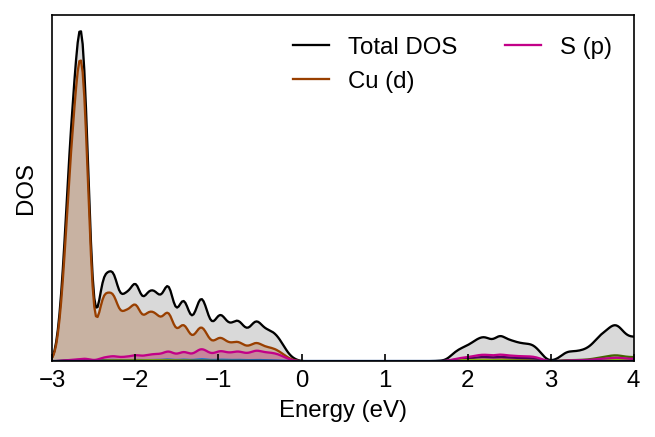

In [5]:
dos.plot_dos(filename="../tests/data/Cu2GeS3/OPT_hybrid/vasprun.xml", xmin=-3, xmax=4, gaussian=0.05, save=False)

3. Plot the simulated absorption spectrum

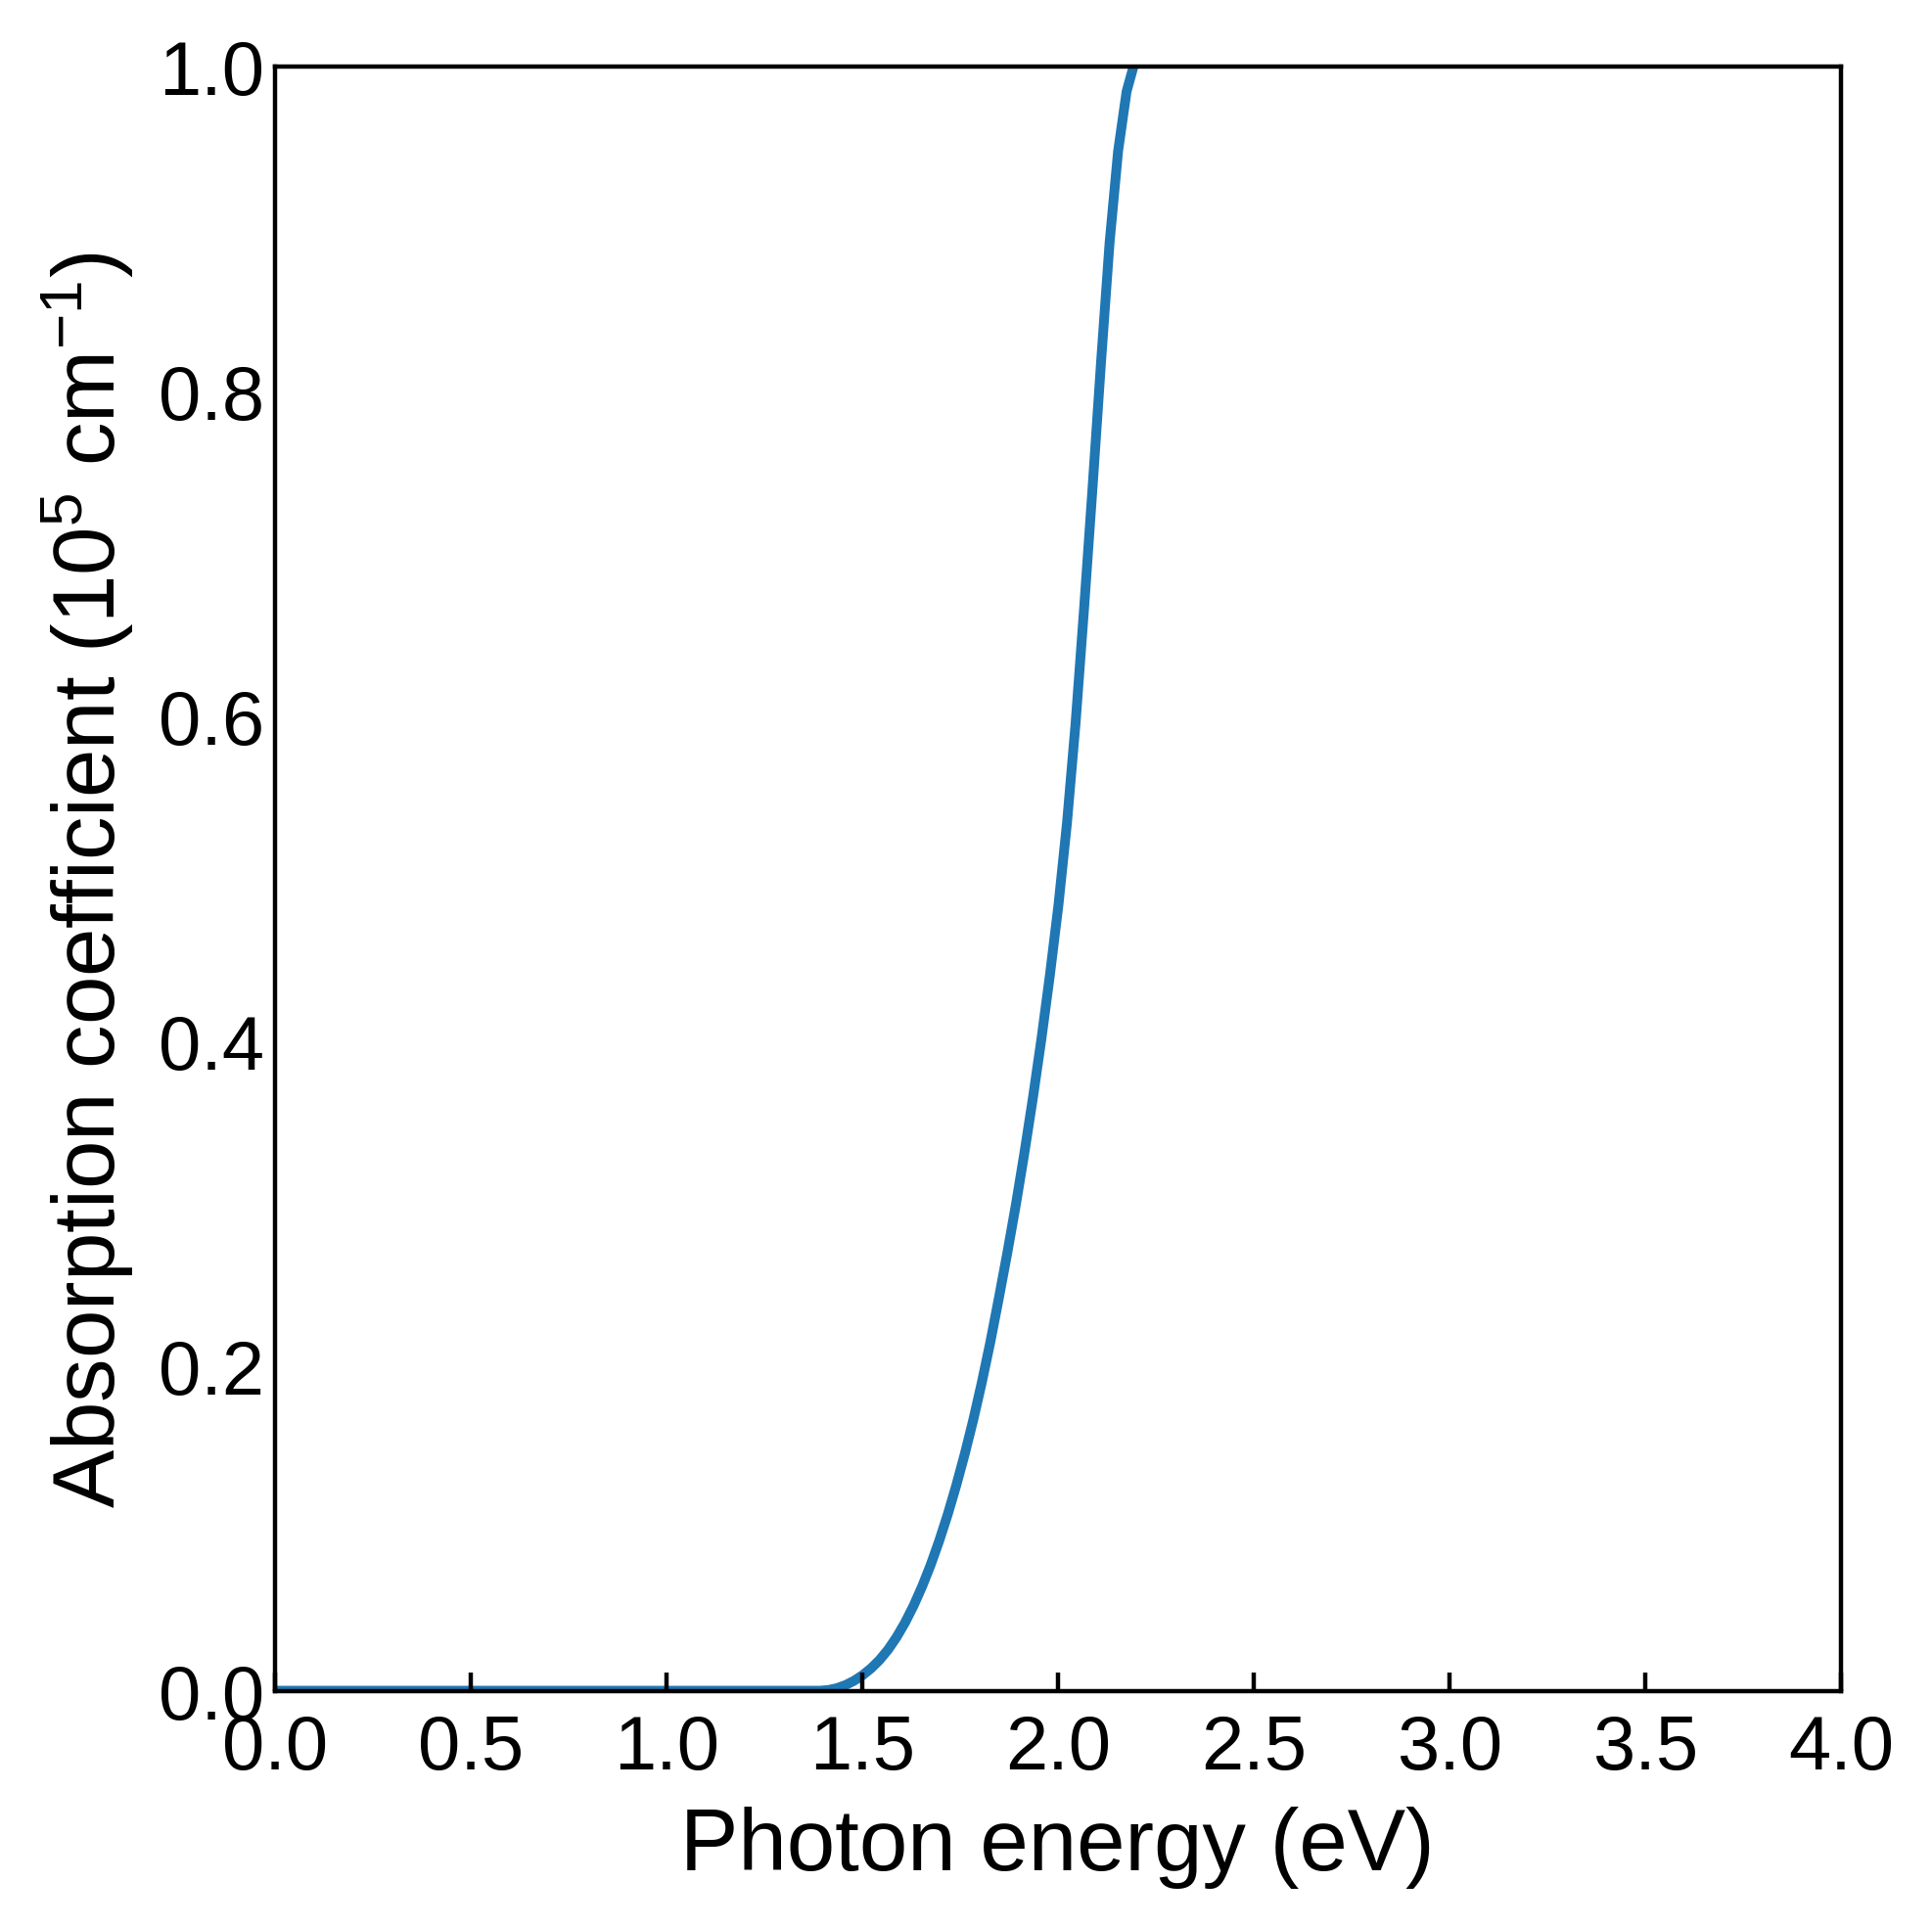

In [12]:
optics.plot_absorption(optics_directory="../tests/data/Cu2GeS3/OPT_hybrid")